# import required libraries 

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_predict
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout
from tensorflow.keras.optimizers import Adam





# Load and Check Data

In [21]:
#true_df = pd.read_csv("https://drive.google.com/file/d/1FBHLmRhDtD9zFsuYupajb3ANyBVdG50j/view?usp=drive_link")
#fake_df = pd.read_csv("https://drive.google.com/file/d/1ktQu00sC49tNGX-nvkOODfx0f0jTdwFY/view?usp=drive_link")

file_id = "1FBHLmRhDtD9zFsuYupajb3ANyBVdG50j"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

true_df = pd.read_csv(url)

file_id = "1ktQu00sC49tNGX-nvkOODfx0f0jTdwFY"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
fake_df = pd.read_csv(url)

true_df['label'] = 0
fake_df['label'] = 1

df = pd.concat([true_df, fake_df]).sample(frac=1).reset_index(drop=True)
df['text'] = df['title'] + " " + df['text']
df.drop(['title', 'subject', 'date'], axis=1, inplace=True)

In [22]:
true_df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [23]:
fake_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [24]:
true_df.tail()

,title,text,subject,date,label
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",0
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",0
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",0
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",0
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",0


In [25]:
df.head()

,text,label
0,Bernie Criticizes Israel’s ‘Disproportionate’...,1
1,OBAMACARE: Wheels Slowly Falling Off The Socia...,1
2,Boys 'cried from barred windows' as Islamic sc...,0
3,NEW YORK MAN SHOCKED To Discover Who Was Steal...,1
4,GINGRICH RIPS “Open Borders” Paul Ryan For Not...,1


# Visualization

# 1.Count of Fake and Real Data



label
1    23481
0    21417
Name: count, dtype: int64


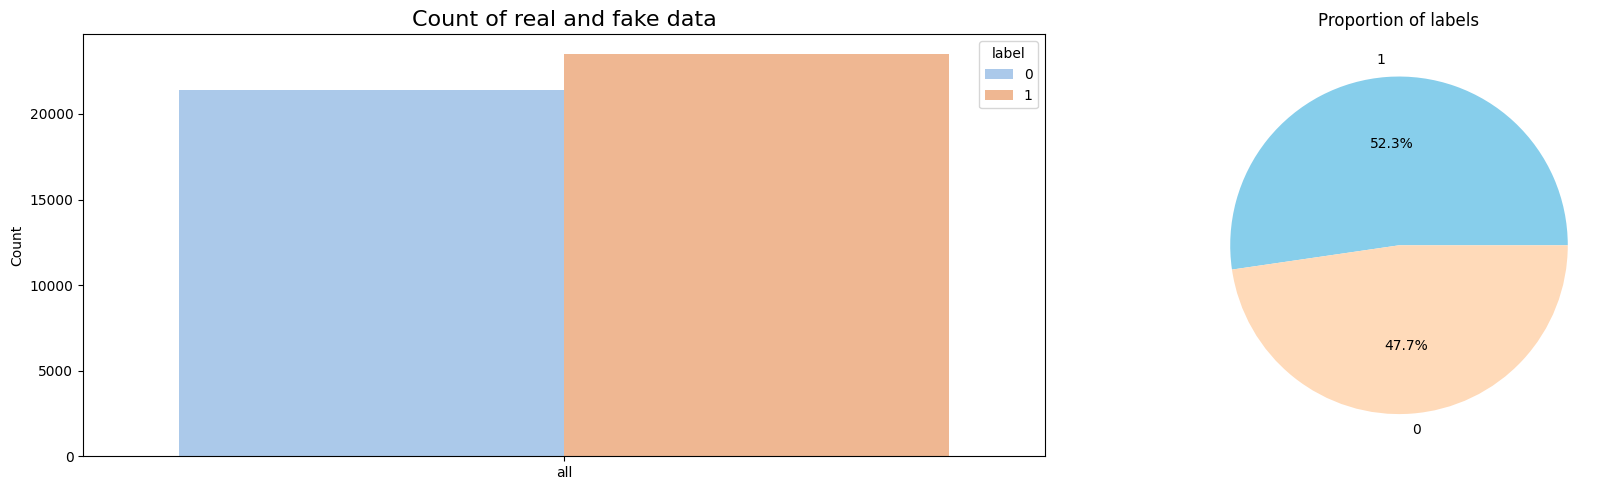

In [26]:
# Print counts
print(df['label'].value_counts())
# Create 1x2 subplots
fig, ax = plt.subplots(1,2, figsize=(19, 5))
# Use hue explicitly so palette is unambiguous (avoids seaborn FutureWarning)
# we create a constant x so bars are colored by the 'label' hue
df['_one'] = 'all'
# show bars side-by-side (dodge=True) so both categories are visible
g1 = sns.countplot(x='_one', hue='label', data=df, ax=ax[0], palette='pastel', dodge=True, hue_order=sorted(df['label'].unique()))
g1.set_title('Count of real and fake data', fontsize=16)
g1.set_ylabel('Count')
g1.set_xlabel('')
# remove helper column to keep df clean
df.drop(columns=['_one'], inplace=True)
# Draw pie chart on the second axes
counts = df['label'].value_counts()
ax[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=['SkyBlue','PeachPuff'])
ax[1].set_title('Proportion of labels')
plt.tight_layout()
plt.show()

# Clean Text

In [27]:
# Data Preprocessing

nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text.lower())
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\raviu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\raviu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Text Feature Extraction Using TF-IDF
Objective: Convert cleaned text data into numerical features for machine learning.

Output:
- X: TF-IDF feature matrix (shape: n_samples × 5000)
- y: Label vector for classification




In [28]:
# Feature Extraction
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['cleaned_text'])
y = df['label']

### Compare Logistic Regression and Multinomial Naive Bayes with Stratified K-Fold CV

In [29]:

# Prepare estimators
lr = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=1000)
nb = MultinomialNB()

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use accuracy and ROC AUC as scoring metrics
scoring = {'accuracy':'accuracy', 'roc_auc':'roc_auc'}

print('Running 5-fold Stratified CV on full TF-IDF features...')
cv_lr = cross_validate(lr, X, y, cv=skf, scoring=scoring, n_jobs=-1)
cv_nb = cross_validate(nb, X, y, cv=skf, scoring=scoring, n_jobs=-1)

def summarize_cv(cv_res, name):
    acc = cv_res['test_accuracy']
    aucs = cv_res['test_roc_auc']
    print(f"\n{name} — accuracy: {acc.mean():.4f} ± {acc.std():.4f}, ROC-AUC: {aucs.mean():.4f} ± {aucs.std():.4f}")

summarize_cv(cv_lr, 'LogisticRegression')
summarize_cv(cv_nb, 'MultinomialNB')

# Fit the logistic model to be used later
lr.fit(X, y)
# Save fitted models to variables that the rest of the notebook can reuse if desired
model_lr_cv = lr
model_nb_cv = nb

Running 5-fold Stratified CV on full TF-IDF features...

LogisticRegression — accuracy: 0.9895 ± 0.0016, ROC-AUC: 0.9991 ± 0.0001

MultinomialNB — accuracy: 0.9456 ± 0.0017, ROC-AUC: 0.9865 ± 0.0009


## Plot cross-validation results for Logistic Regression and MultinomialNB

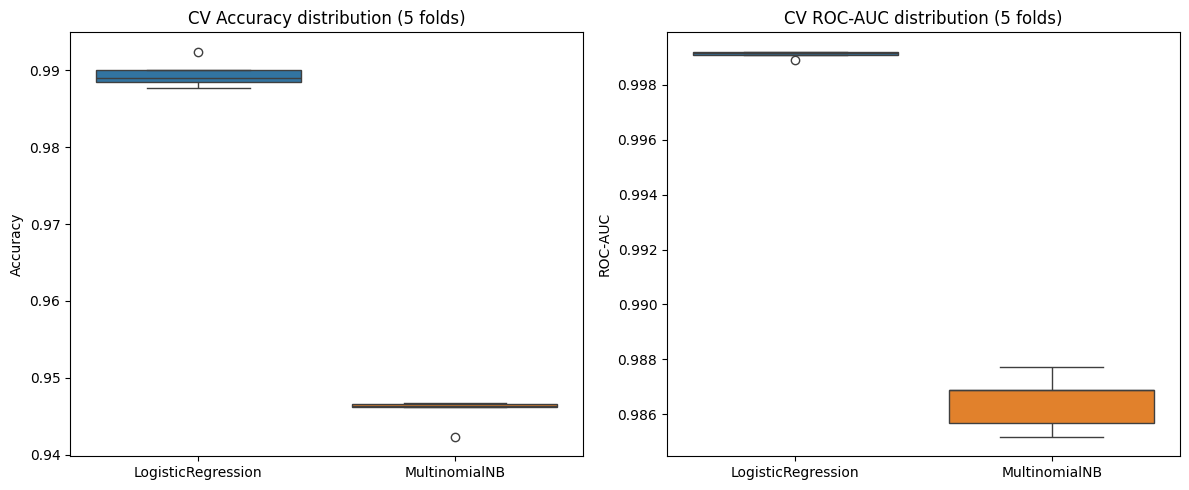

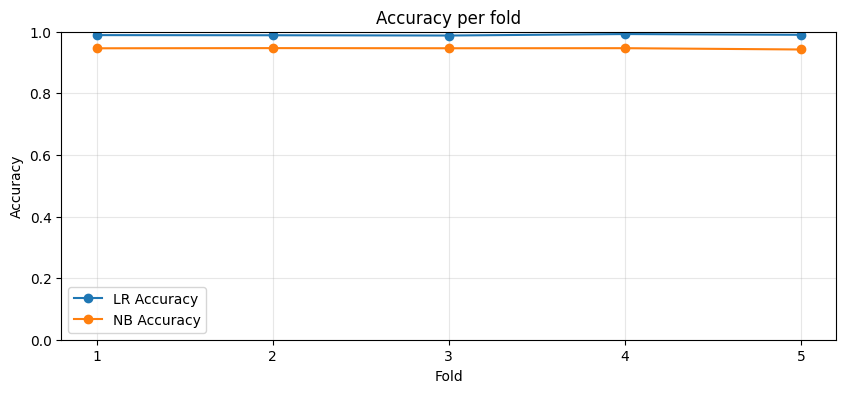

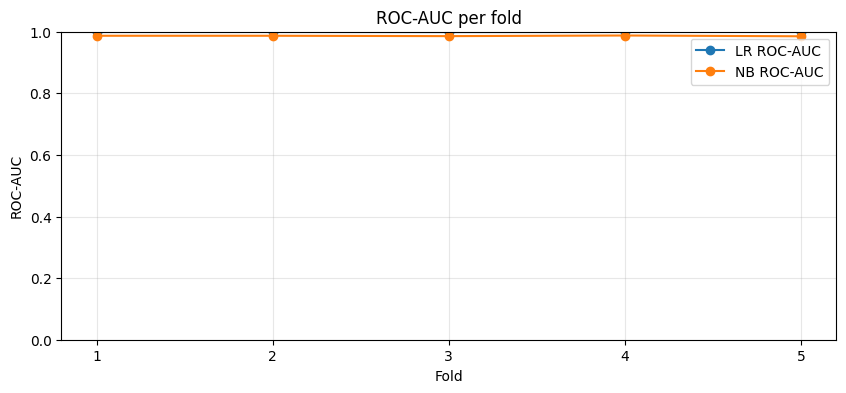

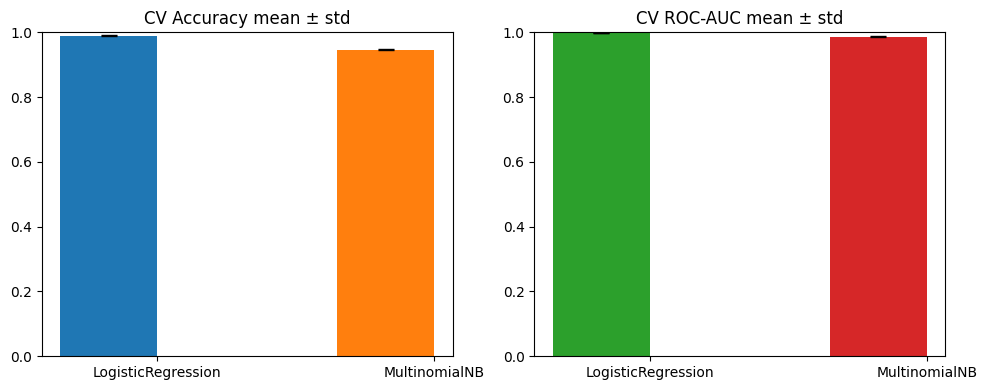

In [30]:

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Ensure cv results exist
try:
    acc_lr = cv_lr['test_accuracy']
    auc_lr = cv_lr['test_roc_auc']
    acc_nb = cv_nb['test_accuracy']
    auc_nb = cv_nb['test_roc_auc']
except NameError:
    raise NameError('cv_lr and cv_nb are not defined. Run the CV cell first.')

# Boxplots for accuracy and ROC-AUC
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=[acc_lr, acc_nb])
plt.xticks([0,1], ['LogisticRegression', 'MultinomialNB'])
plt.title('CV Accuracy distribution (5 folds)')
plt.ylabel('Accuracy')

plt.subplot(1,2,2)
sns.boxplot(data=[auc_lr, auc_nb])
plt.xticks([0,1], ['LogisticRegression', 'MultinomialNB'])
plt.title('CV ROC-AUC distribution (5 folds)')
plt.ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

# Per-fold line plot (accuracy and ROC-AUC)
folds = np.arange(1, len(acc_lr)+1)
plt.figure(figsize=(10,4))
plt.plot(folds, acc_lr, marker='o', label='LR Accuracy')
plt.plot(folds, acc_nb, marker='o', label='NB Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy per fold')
plt.xticks(folds)
plt.ylim(0,1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(folds, auc_lr, marker='o', label='LR ROC-AUC')
plt.plot(folds, auc_nb, marker='o', label='NB ROC-AUC')
plt.xlabel('Fold')
plt.ylabel('ROC-AUC')
plt.title('ROC-AUC per fold')
plt.xticks(folds)
plt.ylim(0,1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Bar chart of mean ± std for accuracy and ROC-AUC
means_acc = [np.mean(acc_lr), np.mean(acc_nb)]
stds_acc = [np.std(acc_lr), np.std(acc_nb)]
means_auc = [np.mean(auc_lr), np.mean(auc_nb)]
stds_auc = [np.std(auc_lr), np.std(auc_nb)]

x = np.arange(2)
width = 0.35

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(x - width/2, means_acc, width, yerr=stds_acc, capsize=6, label='Accuracy', color=['#1f77b4','#ff7f0e'])
plt.xticks(x, ['LogisticRegression','MultinomialNB'])
plt.ylim(0,1)
plt.title('CV Accuracy mean ± std')

plt.subplot(1,2,2)
plt.bar(x - width/2, means_auc, width, yerr=stds_auc, capsize=6, label='ROC-AUC', color=['#2ca02c','#d62728'])
plt.xticks(x, ['LogisticRegression','MultinomialNB'])
plt.ylim(0,1)
plt.title('CV ROC-AUC mean ± std')
plt.tight_layout()
plt.show()

### Confusion matrices using out-of-fold predictions (cross_val_predict)

Computing out-of-fold predictions (this re-trains the models across folds)...


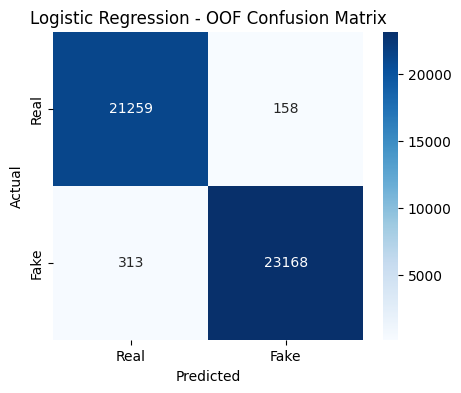

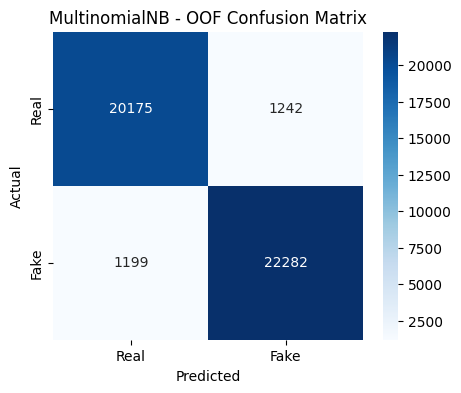

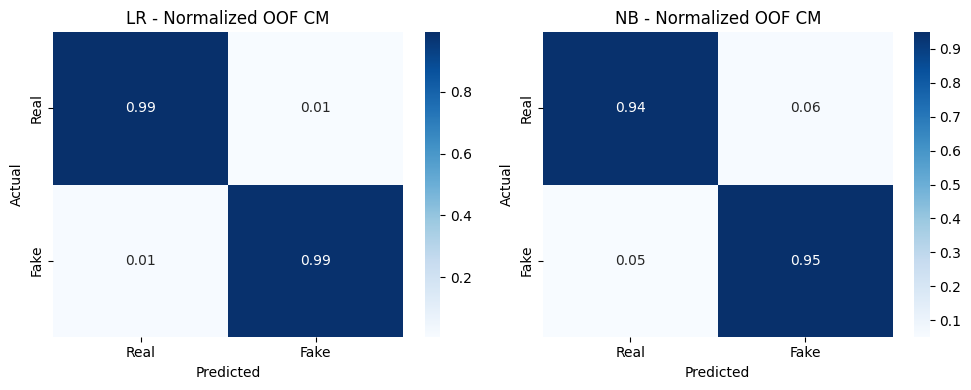


Logistic Regression - OOF Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99     21417
        Fake       0.99      0.99      0.99     23481

    accuracy                           0.99     44898
   macro avg       0.99      0.99      0.99     44898
weighted avg       0.99      0.99      0.99     44898


MultinomialNB - OOF Classification Report:
              precision    recall  f1-score   support

        Real       0.94      0.94      0.94     21417
        Fake       0.95      0.95      0.95     23481

    accuracy                           0.95     44898
   macro avg       0.95      0.95      0.95     44898
weighted avg       0.95      0.95      0.95     44898



In [31]:
# Confusion matrices using out-of-fold predictions (cross_val_predict)

print('Computing out-of-fold predictions (this re-trains the models across folds)...')
# Out-of-fold predictions using the same StratifiedKFold instance
y_oof_lr = cross_val_predict(lr, X, y, cv=skf, method='predict', n_jobs=-1)
y_oof_nb = cross_val_predict(nb, X, y, cv=skf, method='predict', n_jobs=-1)

# Confusion matrices
cm_lr = confusion_matrix(y, y_oof_lr)
cm_nb = confusion_matrix(y, y_oof_nb)

# Helper to plot heatmaps
def plot_cm(cm, title, labels=['Real','Fake']):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

# Raw confusion matrices
plot_cm(cm_lr, 'Logistic Regression - OOF Confusion Matrix')
plot_cm(cm_nb, 'MultinomialNB - OOF Confusion Matrix')

# Normalized confusion matrices (by true class)
cm_lr_norm = (cm_lr.astype('float') / cm_lr.sum(axis=1)[:, np.newaxis])
cm_nb_norm = (cm_nb.astype('float') / cm_nb.sum(axis=1)[:, np.newaxis])

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.heatmap(cm_lr_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title('LR - Normalized OOF CM')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1,2,2)
sns.heatmap(cm_nb_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title('NB - Normalized OOF CM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Classification reports
print('\nLogistic Regression - OOF Classification Report:')
print(classification_report(y, y_oof_lr, target_names=['Real','Fake']))

print('\nMultinomialNB - OOF Classification Report:')
print(classification_report(y, y_oof_nb, target_names=['Real','Fake']))




## Model Training: Logistic Regression
### Objective: Train a binary classifier to detect fake vs real news using TF-IDF features.
## Output:
### - A trained logistic regression model ready for evaluation and prediction



              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4284
           1       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



<Axes: >

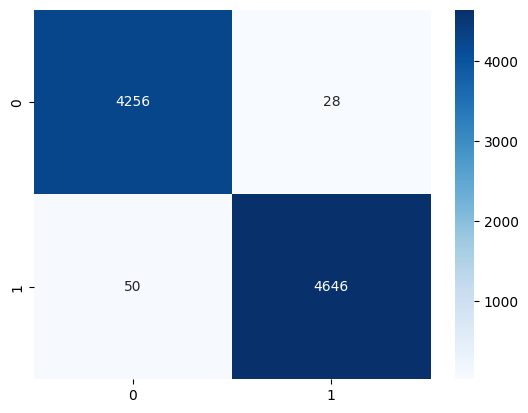

In [59]:
# Train Logistic Regression on TF-IDF features (use TF-IDF split variables if present)
try:
    # prefer the TF-IDF split prepared earlier
    X_train_tfidf = X_tfidf_train
    X_test_tfidf = X_tfidf_test
    y_train_tfidf = y_tfidf_train
    y_test_tfidf = y_tfidf_test
except NameError:
    # fallback: create a split from X,y
    from sklearn.model_selection import train_test_split as _tt
    X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = _tt(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=1000)
model.fit(X_train_tfidf, y_train_tfidf)

# Confusion matrices on the hold-out test set
y_test_pred = model.predict(X_test_tfidf)
print(classification_report(y_test_tfidf, y_test_pred))
sns.heatmap(confusion_matrix(y_test_tfidf, y_test_pred), annot=True, fmt='d', cmap='Blues')


## Model Evaluation: Logistic Regression
## Objective:
### Assess the performance of the trained model on unseen test data.

## Output:
### - y_pred: Predicted labels for test data
### - Printed metrics help evaluate accuracy, balance, and robustness of the model


In [60]:
# Evaluate Logistic Regression on TF-IDF test set
try:
    X_test_eval = X_test_tfidf
    y_test_eval = y_test_tfidf
except NameError:
    X_test_eval = X_test
    y_test_eval = y_test

y_pred = model.predict(X_test_eval)
print(classification_report(y_test_eval, y_pred))
print(confusion_matrix(y_test_eval, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_eval, y_pred))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4284
           1       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

[[4256   28]
 [  50 4646]]
ROC-AUC: 0.9914083464163632


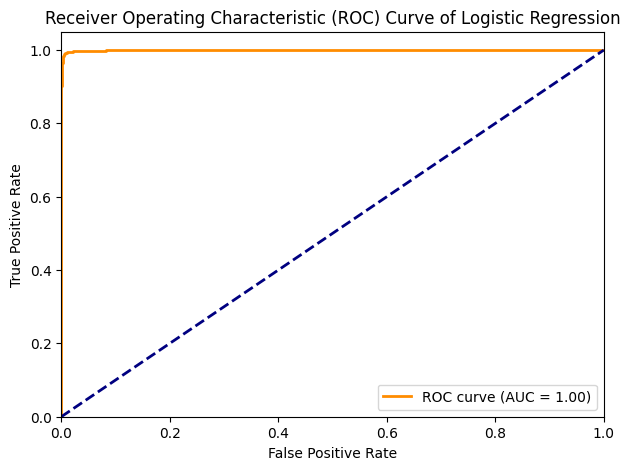

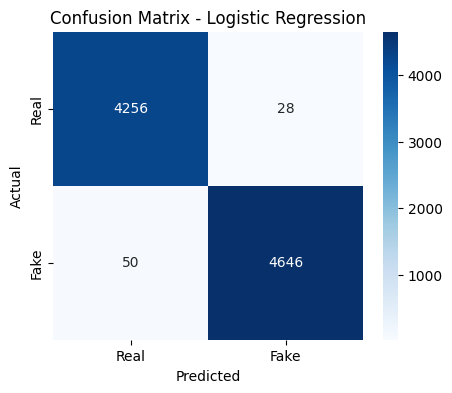

In [61]:
# Plot ROC Curve and Confusion Matrix for Logistic Regression (using TF-IDF test set if available)
from sklearn.metrics import roc_curve, auc

try:
    X_test_plot = X_test_tfidf
    y_test_plot = y_test_tfidf
except NameError:
    X_test_plot = X_test
    y_test_plot = y_test

# ROC Curve
if hasattr(model, 'predict_proba'):
    y_pred_prob = model.predict_proba(X_test_plot)[:, 1]
else:
    # fallback to decision function
    y_pred_prob = model.decision_function(X_test_plot)

fpr, tpr, thresholds = roc_curve(y_test_plot, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve of Logistic Regression')
plt.legend(loc='lower right')
plt.show()

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test_plot, model.predict(X_test_plot))
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


# Deep Learning Model: Feedforward Neural Network for fake news detection 
### Objective:
### Train a binary classifier to detect fake vs real news using TF-IDF features.

## 🧪 Model Architecture
- Input Layer:
- Accepts TF-IDF feature vectors (input_shape = X_train.shape[1])
- Hidden Layers:
- Dense(128, activation='relu')
- Dropout(0.3) to prevent overfitting
- Dense(64, activation='relu')
- Dropout(0.3)
- Output Layer:
- Dense(1, activation='sigmoid') for binary classification

## ⚙️ Compilation & Training
- Optimizer: Adam
- Loss Function: Binary Crossentropy
- Metric: Accuracy
- Training:
- epochs=5, batch_size=64
- validation_split=0.2 (20% of training data used for validation)

## Output:
- A trained deep learning model ready for evaluation and prediction


In [44]:
# Prepare separate TF-IDF train/test arrays for the feedforward deep-learning model
# (use distinct names so we don't overwrite sequence-based X_train used by LSTM/CNN sections)
from sklearn.model_selection import train_test_split as _ttsplit
X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test = _ttsplit(X, y, test_size=0.2, random_state=42, stratify=y)
# Convert sparse matrices to dense arrays if necessary
X_tfidf_train_arr = X_tfidf_train.toarray() if hasattr(X_tfidf_train, 'toarray') else X_tfidf_train
X_tfidf_test_arr = X_tfidf_test.toarray() if hasattr(X_tfidf_test, 'toarray') else X_tfidf_test

print('Prepared TF-IDF train/test arrays:', X_tfidf_train_arr.shape, X_tfidf_test_arr.shape)


Prepared TF-IDF train/test arrays: (35918, 5000) (8980, 5000)


In [45]:
# Feedforward deep-learning model (uses TF-IDF features — dense arrays prepared earlier)
# Ensure TF-IDF arrays (X_tfidf_train_arr, X_tfidf_test_arr) exist from earlier cell
input_dim = X_tfidf_train_arr.shape[1]

model_dl = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_dl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Fit using TF-IDF dense arrays
history_dl = model_dl.fit(X_tfidf_train_arr, y_tfidf_train, epochs=5, batch_size=64, validation_data=(X_tfidf_test_arr, y_tfidf_test))


c:\Users\raviu\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9690 - loss: 0.0877 - val_accuracy: 0.9923 - val_loss: 0.0236
Epoch 2/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9690 - loss: 0.0877 - val_accuracy: 0.9923 - val_loss: 0.0236
Epoch 2/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9969 - loss: 0.0117 - val_accuracy: 0.9928 - val_loss: 0.0213
Epoch 3/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9969 - loss: 0.0117 - val_accuracy: 0.9928 - val_loss: 0.0213
Epoch 3/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9932 - val_loss: 0.0250
Epoch 4/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9932 - val_loss: 0.0250
Epoch 4/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9994 - loss: 0.0022 - val_accuracy: 0.9934 - val_loss: 0.0248
Epoch 5/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9994 - loss: 0.0022 - val_accuracy: 0.9934

# Model Evaluation: Deep Learning Classifier
Objective:
Evaluate the performance of the trained neural network on test data.

Output:
- Clear metrics to assess accuracy, balance, and robustness
- Visual heatmap for confusion matrix
- ROC-AUC score for overall classification qualit


281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
🔍 Classification Report (Feedforward DL on TF-IDF):
🔍 Classification Report (Feedforward DL on TF-IDF):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4284
           1       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4284
           1       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



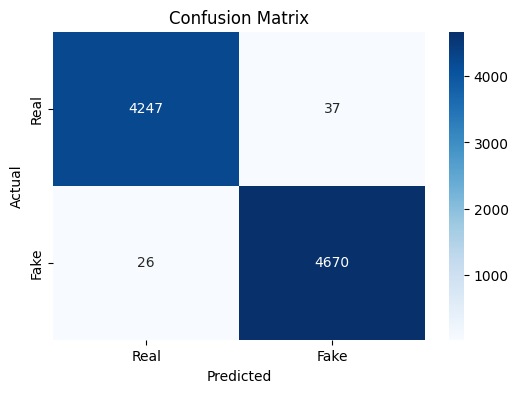

📈 ROC-AUC Score: 0.9996


In [46]:
# Predict on test data using the feedforward deep-learning model trained on TF-IDF features
# Use model_dl and X_tfidf_test_arr, y_tfidf_test

y_pred_prob_dl = model_dl.predict(X_tfidf_test_arr)
y_pred_dl = (y_pred_prob_dl > 0.5).astype("int32")

# Classification report
print("🔍 Classification Report (Feedforward DL on TF-IDF):")
print(classification_report(y_tfidf_test, y_pred_dl))

# Confusion matrix
cm_dl = confusion_matrix(y_tfidf_test, y_pred_dl)
plt.figure(figsize=(6,4))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC-AUC Score
roc_score_dl = roc_auc_score(y_tfidf_test, y_pred_prob_dl)
print(f"📈 ROC-AUC Score: {roc_score_dl:.4f}")


# Modeling using NLP and LSTM

# Train Test Split

In [ ]:
# Display first few entries of cleaned text and labels

print(df['cleaned_text'].head())
print(df['label'].head())

# Split raw text and labels
X_text_train, X_text_test, y_train, y_test = train_test_split(df['cleaned_text'], df['label'], test_size=0.2, random_state=42)


0    bernie criticizes israel disproportionate slau...
1    obamacare wheel slowly falling socialized heal...
2    boy cried barred window islamic school blaze k...
3    new york man shocked discover stealing trump s...
4    gingrich rip open border paul ryan endorsing t...
Name: cleaned_text, dtype: object
0    1
1    1
2    0
3    1
4    1
Name: label, dtype: int64


# Tokenizing
Tokenizing Text -> Repsesenting each word by a number

Mapping of orginal word to number is preserved in word_index property of tokenizer

Lets keep all news to 300, add padding to news with less than 300 words and truncating long ones

In [50]:
max_features = 10000
maxlen = 300

# Text Preprocessing for Deep Learning
Objective:
Convert raw text into padded numerical sequences for neural network input.

Output:
- X_train, X_test: Padded sequences ready for deep learning models (e.g., LSTM, CNN)



In [53]:


# Tokenize raw text
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(X_text_train)

# Convert text to sequences
tokenized_train = tokenizer.texts_to_sequences(X_text_train)
tokenized_test = tokenizer.texts_to_sequences(X_text_test)

# Pad sequences
X_train = pad_sequences(tokenized_train, maxlen=maxlen)
X_test = pad_sequences(tokenized_test, maxlen=maxlen)




# Training LSTM Model


In [54]:
# Deep Learning LSTM model training
batch_size = 256
epochs = 5
embed_size = 100

# Build model
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=max_features, output_dim=embed_size, input_length=maxlen))
model_lstm.add(LSTM(128, return_sequences=True, dropout=0.25, recurrent_dropout=0.25))
model_lstm.add(LSTM(64, dropout=0.1, recurrent_dropout=0.1))
model_lstm.add(Dense(32, activation='relu'))
model_lstm.add(Dropout(0.3))
model_lstm.add(Dense(1, activation='sigmoid'))

# Compile
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
# Note: X_train, y_train, X_test, y_test should be padded sequences prepared earlier in the notebook
history = model_lstm.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_test, y_test)
)

# Evaluate and print accuracy
train_acc = model_lstm.evaluate(X_train, y_train, verbose=0)[1]
test_acc = model_lstm.evaluate(X_test, y_test, verbose=0)[1]
print(f"Accuracy of the model on Training Data is - {train_acc*100:.2f}%")
print(f"Accuracy of the model on Testing Data is - {test_acc*100:.2f}%")


Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 930s 6s/step - accuracy: 0.9267 - loss: 0.2035 - val_accuracy: 0.9834 - val_loss: 0.0563
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 930s 6s/step - accuracy: 0.9267 - loss: 0.2035 - val_accuracy: 0.9834 - val_loss: 0.0563
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 423s 3s/step - accuracy: 0.9836 - loss: 0.0536 - val_accuracy: 0.9878 - val_loss: 0.0422
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 423s 3s/step - accuracy: 0.9836 - loss: 0.0536 - val_accuracy: 0.9878 - val_loss: 0.0422
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 435s 3s/step - accuracy: 0.9935 - loss: 0.0239 - val_accuracy: 0.9844 - val_loss: 0.0571
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 435s 3s/step - accuracy: 0.9935 - loss: 0.0239 - val_accuracy: 0.9844 - val_loss: 0.0571
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 439s 3s/step - accuracy: 0.9954 - loss: 0.0184 - val_accuracy: 0.9843 - val_loss: 0.0462
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 439s 3s/step - accuracy: 0.9954 - loss: 0.0184 - val_accu

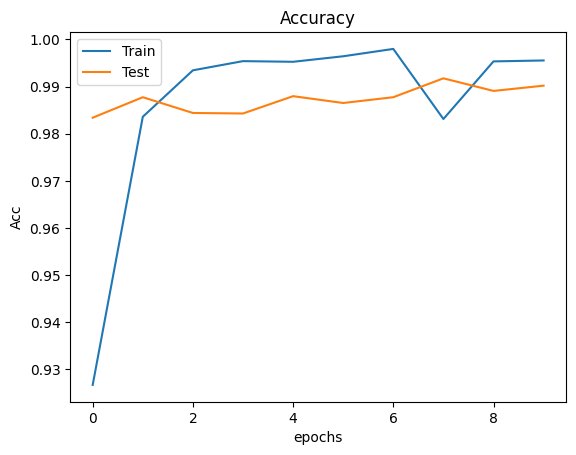

In [55]:
plt.figure()
plt.plot(history.history["accuracy"], label = "Train")
plt.plot(history.history["val_accuracy"], label = "Test")
plt.title("Accuracy")
plt.ylabel("Acc")
plt.xlabel("epochs")
plt.legend()
plt.show()

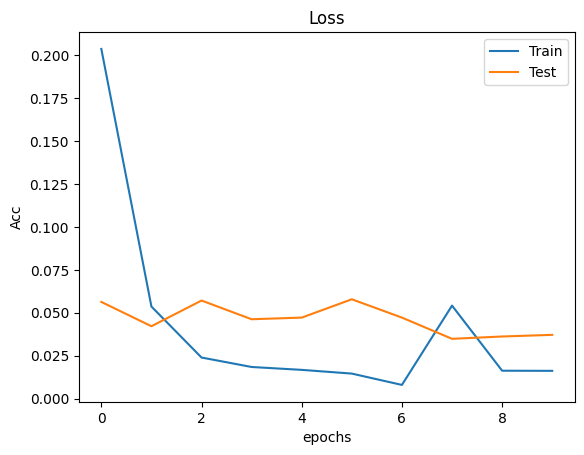

In [56]:
plt.figure()
plt.plot(history.history["loss"], label = "Train")
plt.plot(history.history["val_loss"], label = "Test")
plt.title("Loss")
plt.ylabel("Acc")
plt.xlabel("epochs")
plt.legend()
plt.show()

In [64]:
# Generate predicted probabilities and classification report using the correct test set
# Prefer TF-IDF test variables if present (these match the logistic model); otherwise fall back to X_test/y_test
try:
    X_eval = X_test_tfidf
    y_eval = y_test_tfidf
except NameError:
    X_eval = X_test
    y_eval = y_test

# Use predict_proba when available to get probabilities; otherwise use decision_function
if hasattr(model, 'predict_proba'):
    y_pred_prob = model.predict_proba(X_eval)[:, 1]
else:
    y_pred_prob = model.decision_function(X_eval)

pred = (y_pred_prob > 0.5).astype("int32")
# Print classification report (labels: 0 -> Real, 1 -> Fake)
print(classification_report(y_eval, pred, target_names=['Real', 'Fake']))


              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      4284
        Fake       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



## Final model comparison (improved + plots): LogisticRegression, MultinomialNB, Feedforward DL, LSTM (if available), and K-Fold CV / OOF summaries

Starting final comparison cell — scanning for available models and test splits...
Available variables (True means present): {'model': True, 'nb': True, 'model_nb_cv': True, 'model_dl': True, 'model_lstm': True, 'X_tfidf_test_arr': True, 'y_tfidf_test': True, 'X_test': True, 'y_test': True, 'cv_lr': True, 'cv_nb': True}


,model,accuracy,precision,recall,f1,roc_auc
0,FeedforwardDL,0.9930,0.9921,0.9945,0.9933,0.9996
1,LogisticRegression,0.9913,0.9940,0.9894,0.9917,0.9994
2,LSTM,0.9902,0.9938,0.9874,0.9906,0.9989
3,LR_5fold_CV_mean,0.9895,NaN,NaN,NaN,0.9991
4,MultinomialNB,0.9469,0.9457,0.9532,0.9494,0.9874
5,MultinomialNB_OOF,0.9456,0.9472,0.9489,0.9481,NaN
6,NB_5fold_CV_mean,0.9456,NaN,NaN,NaN,0.9865


C:\Users\raviu\AppData\Local\Temp\ipykernel_9404\2461026287.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='accuracy', y='model', data=acc_df, palette='viridis')


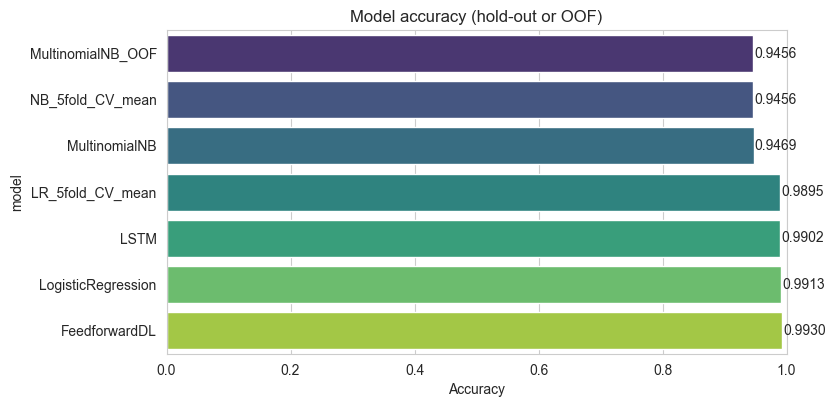

C:\Users\raviu\AppData\Local\Temp\ipykernel_9404\2461026287.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='roc_auc', y='model', data=roc_df, palette='magma')


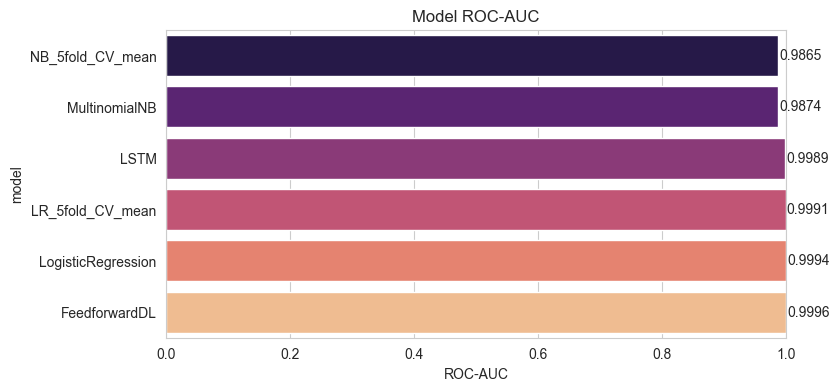

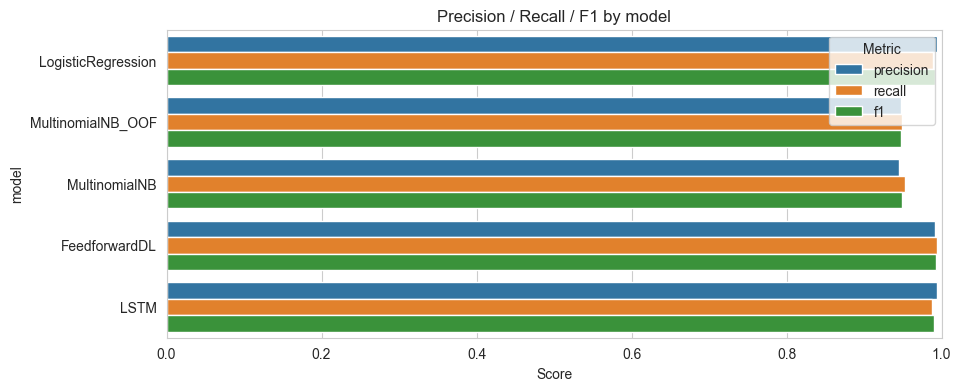

Saved plots: ['model_accuracy.png', 'model_roc_auc.png', 'model_prf.png']
Saved comparison table to model_comparison_summary.csv


In [72]:
# Final model comparison (improved + plots): LogisticRegression, MultinomialNB, Feedforward DL, LSTM (if available), and K-Fold CV / OOF summaries
import pandas as _pd
import numpy as _np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils.validation import check_is_fitted
import os

results = []

print('Starting final comparison cell — scanning for available models and test splits...')
available = {k: k in globals() for k in ['model','nb','model_nb_cv','model_dl','model_lstm','X_tfidf_test_arr','y_tfidf_test','X_test','y_test','cv_lr','cv_nb']}
print('Available variables (True means present):', available)

def compute_metrics_from_preds(y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob) if (y_prob is not None) else None
    return acc, prec, rec, f1, auc

# 1) Logistic Regression (model)
if 'model' in globals():
    try:
        X_eval = globals().get('X_test_tfidf', globals().get('X_test'))
        y_eval = globals().get('y_test_tfidf', globals().get('y_test'))
        if X_eval is not None and y_eval is not None:
            if hasattr(model, 'predict_proba'):
                probs = model.predict_proba(X_eval)[:, 1]
            else:
                probs = None
            preds = model.predict(X_eval)
            acc, prec, rec, f1, auc = compute_metrics_from_preds(y_eval, preds, probs)
            results.append({'model':'LogisticRegression', 'accuracy':acc, 'precision':prec, 'recall':rec, 'f1':f1, 'roc_auc':auc})
    except Exception as e:
        print('Could not evaluate LogisticRegression:', e)

# 2) MultinomialNB (nb or model_nb_cv)
nb_model = globals().get('nb') or globals().get('model_nb_cv')
if nb_model is not None:
    # OOF preds if available
    if 'y_oof_nb' in globals():
        try:
            y_oof = globals().get('y_oof_nb')
            acc, prec, rec, f1, auc = compute_metrics_from_preds(y, y_oof, None)
            results.append({'model':'MultinomialNB_OOF', 'accuracy':acc, 'precision':prec, 'recall':rec, 'f1':f1, 'roc_auc':None})
        except Exception as e:
            print('Could not evaluate MultinomialNB using OOF preds:', e)
    # ensure fitted
    try:
        check_is_fitted(nb_model)
        fitted = True
    except Exception:
        fitted = False
    if not fitted:
        if 'X_train_tfidf' in globals() and 'y_train_tfidf' in globals():
            try:
                nb_model.fit(X_train_tfidf, y_train_tfidf)
                print('Fitted MultinomialNB on X_train_tfidf for evaluation')
                fitted = True
            except Exception as e:
                print('Could not fit MultinomialNB:', e)
        else:
            print('MultinomialNB not fitted and TF-IDF training data not available to fit it.')
    if fitted:
        try:
            X_eval = globals().get('X_test_tfidf', globals().get('X_test'))
            y_eval = globals().get('y_test_tfidf', globals().get('y_test'))
            if X_eval is not None and y_eval is not None:
                if hasattr(nb_model, 'predict_proba'):
                    probs = nb_model.predict_proba(X_eval)[:, 1]
                else:
                    probs = None
                preds = nb_model.predict(X_eval)
                acc, prec, rec, f1, auc = compute_metrics_from_preds(y_eval, preds, probs)
                results.append({'model':'MultinomialNB', 'accuracy':acc, 'precision':prec, 'recall':rec, 'f1':f1, 'roc_auc':auc})
        except Exception as e:
            print('Could not evaluate MultinomialNB after fitting:', e)

# 3) Feedforward deep learning model (model_dl) — TF-IDF arrays
if 'model_dl' in globals():
    try:
        preds_prob = model_dl.predict(globals().get('X_tfidf_test_arr'), verbose=0)
        preds = (preds_prob > 0.5).astype('int32')
        acc, prec, rec, f1s, auc = compute_metrics_from_preds(globals().get('y_tfidf_test'), preds, preds_prob)
        results.append({'model':'FeedforwardDL', 'accuracy':acc, 'precision':prec, 'recall':rec, 'f1':f1s, 'roc_auc':auc})
    except Exception as e:
        print('Could not evaluate FeedforwardDL:', e)

# 4) LSTM (if trained) — uses sequence X_test / y_test
if 'model_lstm' in globals():
    try:
        preds_prob = model_lstm.predict(globals().get('X_test'), verbose=0)
        preds = (preds_prob > 0.5).astype('int32')
        acc, prec, rec, f1s, auc = compute_metrics_from_preds(globals().get('y_test'), preds, preds_prob)
        results.append({'model':'LSTM', 'accuracy':acc, 'precision':prec, 'recall':rec, 'f1':f1s, 'roc_auc':auc})
    except Exception as e:
        print('Could not evaluate LSTM:', e)

# 5) K-Fold CV summaries (mean accuracy, mean ROC-AUC)
try:
    if 'cv_lr' in globals():
        lr_acc_mean = cv_lr['test_accuracy'].mean()
        lr_auc_mean = cv_lr['test_roc_auc'].mean()
        results.append({'model':'LR_5fold_CV_mean', 'accuracy': lr_acc_mean, 'precision':None, 'recall':None, 'f1':None, 'roc_auc': lr_auc_mean})
    if 'cv_nb' in globals():
        nb_acc_mean = cv_nb['test_accuracy'].mean()
        nb_auc_mean = cv_nb['test_roc_auc'].mean()
        results.append({'model':'NB_5fold_CV_mean', 'accuracy': nb_acc_mean, 'precision':None, 'recall':None, 'f1':None, 'roc_auc': nb_auc_mean})
except Exception as e:
    print('Could not extract CV summaries:', e)

# Build DataFrame and format
if results:
    df_results = _pd.DataFrame(results)
    cols = ['model','accuracy','precision','recall','f1','roc_auc']
    for c in cols[1:]:
        if c in df_results.columns:
            df_results[c] = df_results[c].apply(lambda v: round(float(v), 4) if (v is not None and not _np.isnan(v)) else (None if v is None else _np.nan))
    display(df_results[cols].sort_values(by='accuracy', ascending=False).reset_index(drop=True))

    # --- PLOTTING ---
    # Use seaborn style setter which is available with seaborn installation
    sns.set_style('whitegrid')

    out_files = []

    # Accuracy horizontal bar
    acc_df = df_results.dropna(subset=['accuracy']).sort_values(by='accuracy', ascending=True)
    plt.figure(figsize=(8, max(4, len(acc_df)*0.6)))
    sns.barplot(x='accuracy', y='model', data=acc_df, palette='viridis')
    plt.xlim(0,1)
    plt.xlabel('Accuracy')
    plt.title('Model accuracy (hold-out or OOF)')
    for i, v in enumerate(acc_df['accuracy']):
        plt.text(v + 0.002, i, f"{v:.4f}", va='center')
    acc_path = 'model_accuracy.png'
    plt.savefig(acc_path, bbox_inches='tight')
    out_files.append(acc_path)
    plt.show()
    plt.close()

    # ROC-AUC bar (if any non-null)
    if df_results['roc_auc'].notna().any():
        roc_df = df_results.dropna(subset=['roc_auc']).sort_values(by='roc_auc', ascending=True)
        plt.figure(figsize=(8, max(4, len(roc_df)*0.6)))
        sns.barplot(x='roc_auc', y='model', data=roc_df, palette='magma')
        plt.xlim(0,1)
        plt.xlabel('ROC-AUC')
        plt.title('Model ROC-AUC')
        for i, v in enumerate(roc_df['roc_auc']):
            plt.text(v + 0.002, i, f"{v:.4f}", va='center')
        roc_path = 'model_roc_auc.png'
        plt.savefig(roc_path, bbox_inches='tight')
        out_files.append(roc_path)
        plt.show()
        plt.close()

    # Precision/Recall/F1 grouped bars (models that have these metrics)
    prf_df = df_results.dropna(subset=['precision','recall','f1'])
    if not prf_df.empty:
        prf_melt = prf_df.melt(id_vars='model', value_vars=['precision','recall','f1'], var_name='metric', value_name='score')
        plt.figure(figsize=(10, max(4, len(prf_df)*0.6)))
        sns.barplot(x='score', y='model', hue='metric', data=prf_melt)
        plt.xlim(0,1)
        plt.xlabel('Score')
        plt.title('Precision / Recall / F1 by model')
        plt.legend(title='Metric')
        prf_path = 'model_prf.png'
        plt.savefig(prf_path, bbox_inches='tight')
        out_files.append(prf_path)
        plt.show()
        plt.close()

    print('Saved plots:', out_files)

    # Optionally, save comparison table
    try:
        df_results.to_csv('model_comparison_summary.csv', index=False)
        print('Saved comparison table to model_comparison_summary.csv')
    except Exception:
        pass

else:
    print('No results to display — ensure the models have been trained and TF-IDF test splits exist.')


### Consolidated 5-fold Stratified CV comparison: LogisticRegression, MultinomialNB, optional Feedforward DL
### - Fits TF-IDF vectorizer if not present
### - Runs StratifiedKFold(n_splits=5) and trains/evaluates LR and NB per fold
### - Optionally trains a small feedforward DL per fold if TensorFlow is installed
### - Saves per-fold metrics, CSV summary, plots, and serializes final fitted vectorizer + classical models (joblib)


Using existing `vectorizer` from workspace
TensorFlow available — will attempt optional DL per-fold (may be slower).
=== Fold 1 ===
TensorFlow available — will attempt optional DL per-fold (may be slower).
=== Fold 1 ===


c:\Users\raviu\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


=== Fold 2 ===


c:\Users\raviu\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


=== Fold 3 ===


...

=== Fold 5 ===


c:\Users\raviu\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Cross-validation summary (5-fold):


,model,accuracy_mean,accuracy_std,roc_auc_mean,roc_auc_std
0,LogisticRegression,0.989510,0.001641,0.999114,0.000107
1,MultinomialNB,0.945632,0.001672,0.986470,0.000915
2,FeedforwardDL,0.993363,0.000864,0.999485,0.000164


Saved cv_summary_5fold.csv
Saved tfidf_vectorizer.joblib, final_logistic.joblib, final_nb.joblib
Saved tfidf_vectorizer.joblib, final_logistic.joblib, final_nb.joblib


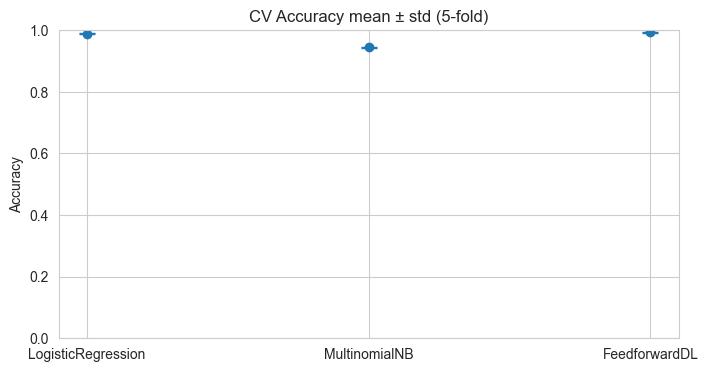

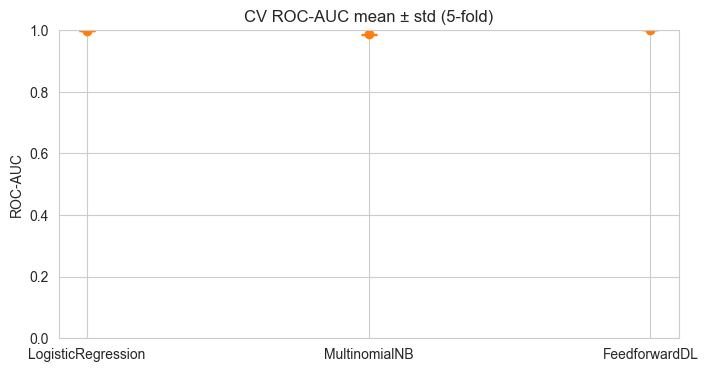

Saved cv_accuracy_summary.png and (if available) cv_roc_auc_summary.png
Per-fold detailed results:
{'fold': 1, 'lr': {'acc': 0.9889755011135858, 'prec': 0.9912393162393163, 'rec': 0.9876516925697254, 'f1': 0.9894422523195052, 'auc': 0.9990958009123613}, 'nb': {'acc': 0.9462138084632516, 'prec': 0.9460203217612193, 'rec': 0.9514583776878859, 'f1': 0.9487315571595372, 'auc': 0.9868824522793894}, 'dl': {'acc': 0.9924276169265034, 'prec': 0.9910884786760026, 'rec': 0.994464551841601, 'f1': 0.9927736450584485, 'auc': 0.9992996558028729}}
{'fold': 2, 'lr': {'acc': 0.9885300668151448, 'prec': 0.9933404940923738, 'rec': 0.9846678023850085, 'f1': 0.9889851352796493, 'auc': 0.9991651118141749}, 'nb': {'acc': 0.9467706013363029, 'prec': 0.9491056218057922, 'rec': 0.9491056218057922, 'f1': 0.9491056218057922, 'auc': 0.9868718853242603}, 'dl': {'acc': 0.9922048997772829, 'prec': 0.990874363327674, 'rec': 0.9942504258943782, 'f1': 0.9925595238095238, 'auc': 0.9997261113417542}}
{'fold': 3, 'lr': {'a

In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

# Ensure TF-IDF vectorizer exists (fit on full dataset if needed)
if 'vectorizer' not in globals():
    print('Fitting TfidfVectorizer on the full cleaned_text corpus...')
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
    X_full = vectorizer.fit_transform(df['cleaned_text'])
    y_full = df['label'].values
else:
    print('Using existing `vectorizer` from workspace')
    X_full = vectorizer.transform(df['cleaned_text'])
    y_full = df['label'].values

# Prepare K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Placeholders for results
fold_results = []
models_final = {'logistic': None, 'nb': None}

# Check if TensorFlow / Keras available for optional feedforward DL
use_dl = False
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    use_dl = True
    print('TensorFlow available — will attempt optional DL per-fold (may be slower).')
except Exception:
    print('TensorFlow not available; skipping deep-learning per-fold training.')

# Per-fold training
fold_idx = 0
for train_idx, test_idx in skf.split(X_full, y_full):
    fold_idx += 1
    print(f'=== Fold {fold_idx} ===')
    X_train_fold = X_full[train_idx]
    X_test_fold = X_full[test_idx]
    y_train_fold = y_full[train_idx]
    y_test_fold = y_full[test_idx]

    # Logistic Regression
    lr = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=1000)
    lr.fit(X_train_fold, y_train_fold)
    y_pred_lr = lr.predict(X_test_fold)
    y_prob_lr = lr.predict_proba(X_test_fold)[:,1] if hasattr(lr, 'predict_proba') else None

    # Multinomial NB
    nb = MultinomialNB()
    nb.fit(X_train_fold, y_train_fold)
    y_pred_nb = nb.predict(X_test_fold)
    y_prob_nb = nb.predict_proba(X_test_fold)[:,1] if hasattr(nb, 'predict_proba') else None

    # Optional DL: small feedforward model trained on dense arrays
    dl_metrics = {'acc': None, 'prec': None, 'rec': None, 'f1': None, 'auc': None}
    if use_dl:
        try:
            X_train_arr = X_train_fold.toarray() if hasattr(X_train_fold, 'toarray') else X_train_fold
            X_test_arr = X_test_fold.toarray() if hasattr(X_test_fold, 'toarray') else X_test_fold
            model_dl_fold = Sequential([
                Dense(128, activation='relu', input_shape=(X_train_arr.shape[1],)),
                Dropout(0.3),
                Dense(64, activation='relu'),
                Dropout(0.3),
                Dense(1, activation='sigmoid')
            ])
            model_dl_fold.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
            # small epochs to keep per-fold time reasonable
            model_dl_fold.fit(X_train_arr, y_train_fold, epochs=3, batch_size=128, verbose=0)
            prob_dl = model_dl_fold.predict(X_test_arr, verbose=0).ravel()
            pred_dl = (prob_dl > 0.5).astype('int32')
            dl_metrics['acc'] = accuracy_score(y_test_fold, pred_dl)
            dl_metrics['prec'] = precision_score(y_test_fold, pred_dl, zero_division=0)
            dl_metrics['rec'] = recall_score(y_test_fold, pred_dl, zero_division=0)
            dl_metrics['f1'] = f1_score(y_test_fold, pred_dl, zero_division=0)
            dl_metrics['auc'] = roc_auc_score(y_test_fold, prob_dl)
        except Exception as e:
            print('DL fold error:', e)
            use_dl = False

    # compute classical metrics
    lr_metrics = {
        'acc': accuracy_score(y_test_fold, y_pred_lr),
        'prec': precision_score(y_test_fold, y_pred_lr, zero_division=0),
        'rec': recall_score(y_test_fold, y_pred_lr, zero_division=0),
        'f1': f1_score(y_test_fold, y_pred_lr, zero_division=0),
        'auc': roc_auc_score(y_test_fold, y_prob_lr) if y_prob_lr is not None else None
    }
    nb_metrics = {
        'acc': accuracy_score(y_test_fold, y_pred_nb),
        'prec': precision_score(y_test_fold, y_pred_nb, zero_division=0),
        'rec': recall_score(y_test_fold, y_pred_nb, zero_division=0),
        'f1': f1_score(y_test_fold, y_pred_nb, zero_division=0),
        'auc': roc_auc_score(y_test_fold, y_prob_nb) if y_prob_nb is not None else None
    }

    fold_results.append({'fold': fold_idx, 'lr': lr_metrics, 'nb': nb_metrics, 'dl': dl_metrics if use_dl else None})

    # keep last fold models as final models (can be replaced with full-data retrain later)
    models_final['logistic'] = lr
    models_final['nb'] = nb

# Summarize per-model metrics across folds
def summarize_metric(results, model_key, metric):
    vals = [r[model_key][metric] for r in results if r[model_key] and r[model_key][metric] is not None]
    return (np.mean(vals), np.std(vals)) if len(vals)>0 else (None, None)

summary_rows = []
for mkey, mname in [('lr','LogisticRegression'), ('nb','MultinomialNB')]:
    acc_mean, acc_std = summarize_metric(fold_results, mkey, 'acc')
    auc_mean, auc_std = summarize_metric(fold_results, mkey, 'auc')
    summary_rows.append({'model': mname, 'accuracy_mean': acc_mean, 'accuracy_std': acc_std, 'roc_auc_mean': auc_mean, 'roc_auc_std': auc_std})

if use_dl:
    dl_vals = [r['dl'] for r in fold_results if r['dl'] and r['dl']['acc'] is not None]
    if dl_vals:
        dl_acc = np.mean([v['acc'] for v in dl_vals])
        dl_acc_std = np.std([v['acc'] for v in dl_vals])
        dl_auc = np.mean([v['auc'] for v in dl_vals])
        dl_auc_std = np.std([v['auc'] for v in dl_vals])
        summary_rows.append({'model':'FeedforwardDL','accuracy_mean':dl_acc,'accuracy_std':dl_acc_std,'roc_auc_mean':dl_auc,'roc_auc_std':dl_auc_std})

summary_df = pd.DataFrame(summary_rows)
print('\nCross-validation summary (5-fold):')
display(summary_df)

# Save summary and artifacts
summary_df.to_csv('cv_summary_5fold.csv', index=False)
print('Saved cv_summary_5fold.csv')

# Save final vectorizer and classical models (retrain on full data before saving for best performance)
try:
    # retrain classical models on full data
    final_lr = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=1000)
    final_lr.fit(X_full, y_full)
    final_nb = MultinomialNB()
    final_nb.fit(X_full, y_full)
    joblib.dump(vectorizer, 'tfidf_vectorizer.joblib')
    joblib.dump(final_lr, 'final_logistic.joblib')
    joblib.dump(final_nb, 'final_nb.joblib')
    print('Saved tfidf_vectorizer.joblib, final_logistic.joblib, final_nb.joblib')
except Exception as e:
    print('Could not save artifacts:', e)

# Plot summary comparisons
plt.figure(figsize=(8,4))
plt.errorbar(summary_df['model'], summary_df['accuracy_mean'], yerr=summary_df['accuracy_std'], fmt='o', capsize=6)
plt.ylim(0,1)
plt.title('CV Accuracy mean ± std (5-fold)')
plt.ylabel('Accuracy')
plt.savefig('cv_accuracy_summary.png', bbox_inches='tight')
plt.show()

if summary_df['roc_auc_mean'].notna().any():
    plt.figure(figsize=(8,4))
    plt.errorbar(summary_df['model'], summary_df['roc_auc_mean'], yerr=summary_df['roc_auc_std'], fmt='o', capsize=6, color='C1')
    plt.ylim(0,1)
    plt.title('CV ROC-AUC mean ± std (5-fold)')
    plt.ylabel('ROC-AUC')
    plt.savefig('cv_roc_auc_summary.png', bbox_inches='tight')
    plt.show()

print('Saved cv_accuracy_summary.png and (if available) cv_roc_auc_summary.png')

print('Per-fold detailed results:')
for r in fold_results:
    print(r)
